In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import calendar
from pandas.api.types import CategoricalDtype

In [10]:
df = pd.read_csv(r"/Users/lingampallysumithreddy/Downloads/netflix_content_2023.csv")

In [11]:
df.head()

,Title,Available Globally?,Release Date,Hours Viewed,Language Indicator,Content Type
0,The Night Agent: Season 1,Yes,2023-03-23,"81,21,00,000",English,Show
1,Ginny & Georgia: Season 2,Yes,2023-01-05,"66,51,00,000",English,Show
2,The Glory: Season 1 // 더 글로리: 시즌 1,Yes,2022-12-30,"62,28,00,000",Korean,Show
3,Wednesday: Season 1,Yes,2022-11-23,"50,77,00,000",English,Show
4,Queen Charlotte: A Bridgerton Story,Yes,2023-05-04,"50,30,00,000",English,Movie


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24812 entries, 0 to 24811
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Title                24812 non-null  object
 1   Available Globally?  24812 non-null  object
 2   Release Date         8166 non-null   object
 3   Hours Viewed         24812 non-null  object
 4   Language Indicator   24812 non-null  object
 5   Content Type         24812 non-null  object
dtypes: object(6)
memory usage: 1.1+ MB


In [13]:
df.describe()

,Title,Available Globally?,Release Date,Hours Viewed,Language Indicator,Content Type
count,24812,24812,8166,24812,24812,24812
unique,19158,2,1783,889,6,2
top,The Night Agent: Season 1,No,2020-03-20,"1,00,000",English,Movie
freq,2,17162,28,4046,17268,14104


In [14]:
df.isnull().sum()

Title                      0
Available Globally?        0
Release Date           16646
Hours Viewed               0
Language Indicator         0
Content Type               0
dtype: int64

In [15]:
df.columns.tolist()



['Title',
 'Available Globally?',
 'Release Date',
 'Hours Viewed',
 'Language Indicator',
 'Content Type']

In [16]:
df['Release Date'] = df['Release Date'].fillna(pd.Timestamp('2000-01-01'))



In [17]:
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')


df['Hours Viewed'] = df['Hours Viewed'].str.replace(",", "")
df['Hours Viewed'] = pd.to_numeric(df['Hours Viewed'], errors='coerce')

df['Available Globally?'] = df['Available Globally?'].str.strip().str.lower() == 'yes'

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [18]:
df.head()

,title,available_globally?,release_date,hours_viewed,language_indicator,content_type
0,The Night Agent: Season 1,True,2023-03-23,812100000,English,Show
1,Ginny & Georgia: Season 2,True,2023-01-05,665100000,English,Show
2,The Glory: Season 1 // 더 글로리: 시즌 1,True,2022-12-30,622800000,Korean,Show
3,Wednesday: Season 1,True,2022-11-23,507700000,English,Show
4,Queen Charlotte: A Bridgerton Story,True,2023-05-04,503000000,English,Movie


In [19]:
df.isnull().sum()

title                  0
available_globally?    0
release_date           0
hours_viewed           0
language_indicator     0
content_type           0
dtype: int64

In [20]:
# Top 10 Titles by Hours Viewed
top_10 = df.sort_values(by='hours_viewed', ascending=False).head(10)
top_10[['title', 'hours_viewed']]

,title,hours_viewed
0,The Night Agent: Season 1,812100000
1,Ginny & Georgia: Season 2,665100000
18227,King the Land: Limited Series // 킹더랜드: 리미티드 시리즈,630200000
2,The Glory: Season 1 // 더 글로리: 시즌 1,622800000
18214,ONE PIECE: Season 1,541900000
3,Wednesday: Season 1,507700000
4,Queen Charlotte: A Bridgerton Story,503000000
5,You: Season 4,440600000
6,La Reina del Sur: Season 3,429600000
7,Outer Banks: Season 3,402500000


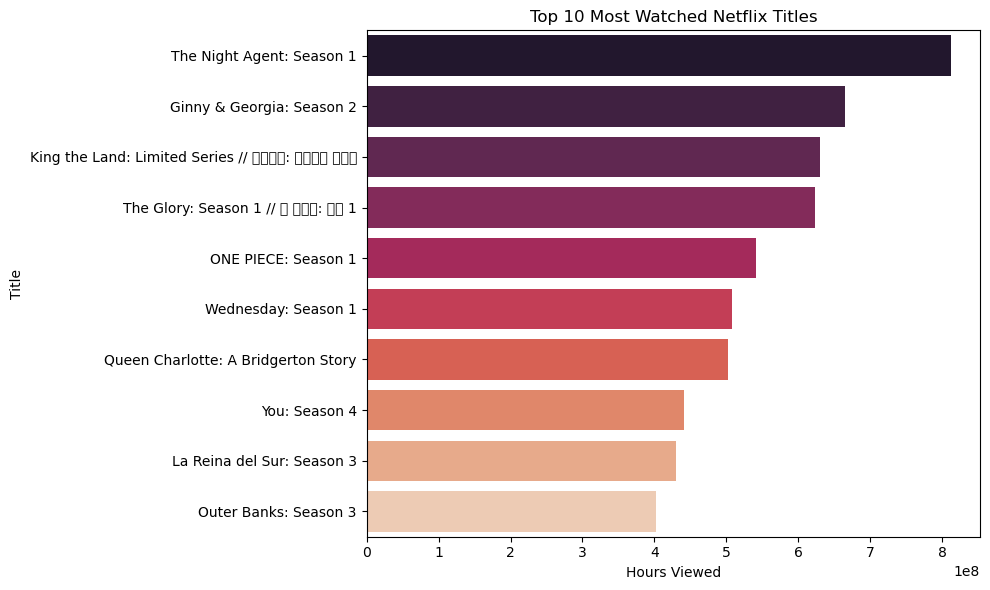

In [21]:
# Graph: Horizontal Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x='hours_viewed', y='title', palette='rocket')
plt.title('Top 10 Most Watched Netflix Titles')
plt.xlabel('Hours Viewed')
plt.ylabel('Title')
plt.tight_layout()
plt.show()

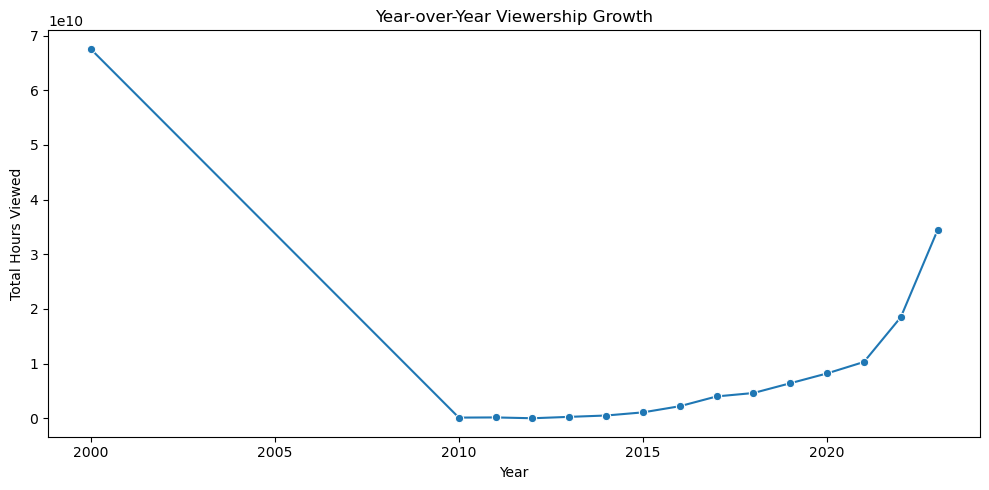

In [22]:
# Year-over-Year Viewership Growth
df['release_year'] = df['release_date'].dt.year
yearly_viewership = df.groupby('release_year')['hours_viewed'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_viewership, x='release_year', y='hours_viewed', marker='o')
plt.title('Year-over-Year Viewership Growth')
plt.xlabel('Year')
plt.ylabel('Total Hours Viewed')
plt.tight_layout()
plt.show()

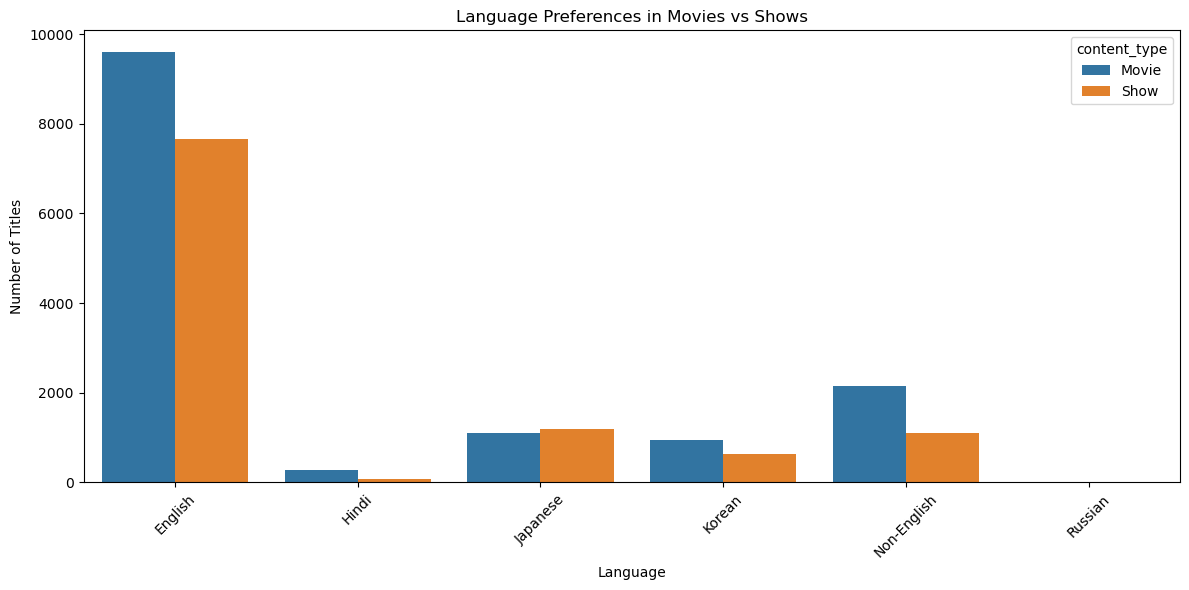

In [23]:
#Language Preferences in Movies vs. Shows
lang_type = df.groupby(['content_type', 'language_indicator']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=lang_type, x='language_indicator', y='count', hue='content_type')
plt.title('Language Preferences in Movies vs Shows')
plt.xlabel('Language')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

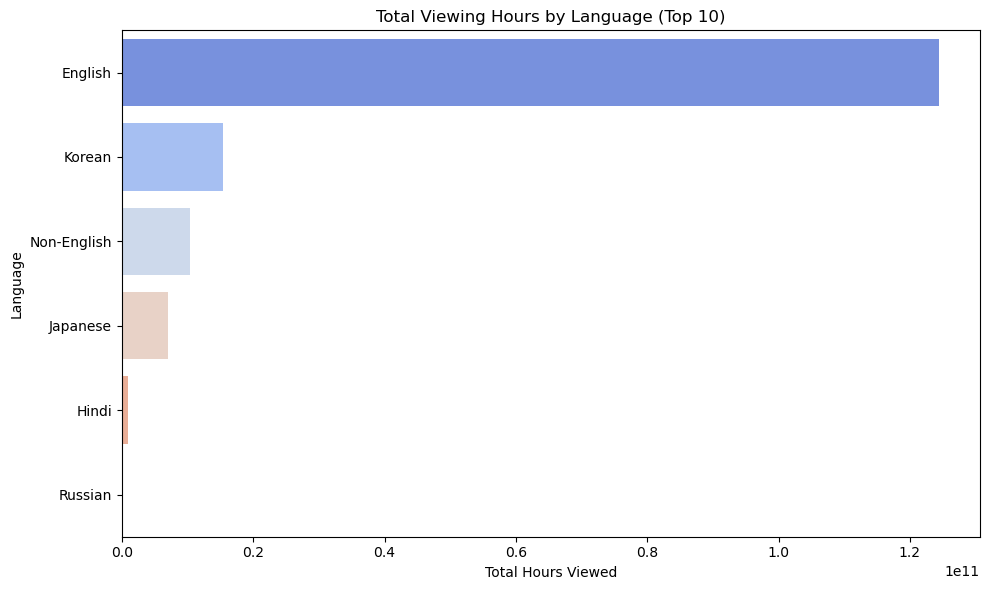

In [24]:
#Total Viewing Hours by Language
lang_hours = df.groupby('language_indicator')['hours_viewed'].sum().reset_index()
lang_hours = lang_hours.sort_values(by='hours_viewed', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=lang_hours, x='hours_viewed', y='language_indicator', palette='coolwarm')
plt.title('Total Viewing Hours by Language (Top 10)')
plt.xlabel('Total Hours Viewed')
plt.ylabel('Language')
plt.tight_layout()
plt.show()

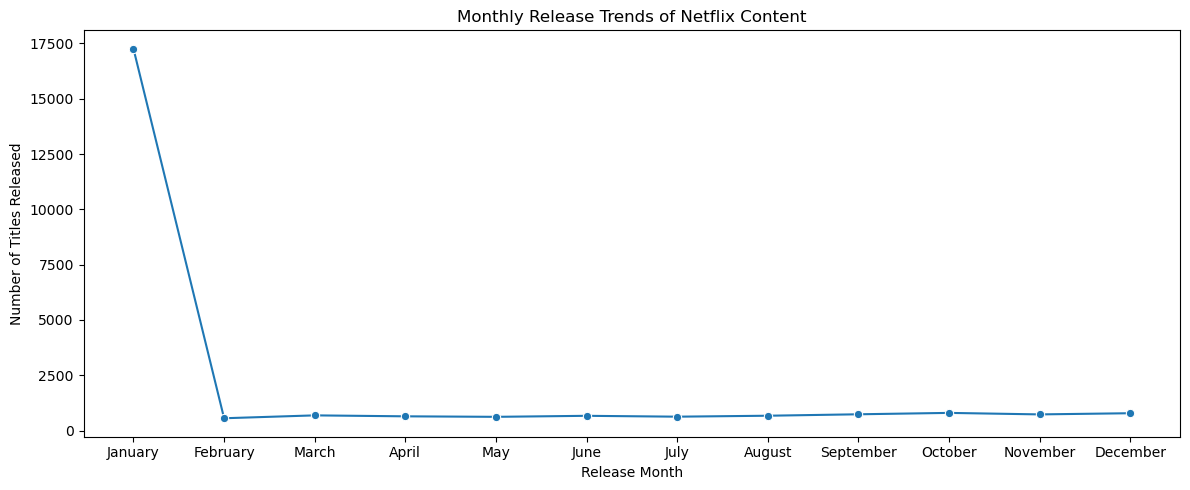

In [25]:
# Monthly Release Trends of Netflix Content
df['release_month'] = df['release_date'].dt.month_name()

# Define month order
month_order = list(calendar.month_name[1:])  # ['January', 'February', ..., 'December']
month_type = CategoricalDtype(categories=month_order, ordered=True)

df['release_month'] = df['release_month'].astype(month_type)

monthly_release = df.groupby('release_month').size().reset_index(name='count')

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_release, x='release_month', y='count', marker='o')
plt.title('Monthly Release Trends of Netflix Content')
plt.xlabel('Release Month')
plt.ylabel('Number of Titles Released')
plt.tight_layout()
plt.show()

